In [24]:
import pandas as pd

# 1. Load datasets
import pandas as pd

# Load all datasets
store_df = pd.read_csv("store_data.csv")
sales_df = pd.read_csv("sales_data.csv")
product_df = pd.read_csv("product_data.csv")
customer_df = pd.read_csv("customer_data.csv")

# Clean store_df column names
store_df.columns = (
    store_df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('[^a-zA-Z0-9_]', '', regex=True)
)


In [23]:
store_df = pd.read_csv("store_data.csv")
store_df.head()

,store_id,store_name,region,store_size_m2
0,S001,Lisbon Flagship,Lisbon,179
1,S002,Porto Center,Porto,728
2,S003,Faro Outlet,Algarve,336
3,S004,Online,Online,950
4,S005,Coimbra Boutique,Coimbra,238


In [21]:
product_df = pd.read_csv("product_data.csv")
product_df.head()

,product_id,category,color,size,season,supplier,cost_price,list_price
0,P000001,Bottoms,Black,XL,Spring,supplierb,78.26,46.45
1,P000002,???,Black,M,Summer,supplierc,39.67,147.82
2,P000003,Tops,Black,XL,Summer,supplierd,27.62,44.40
3,P000004,Accessories,White,XL,Winter,supplierb,7.43,68.49
4,P000005,Accessories,NaN,XL,Fall,suppliera,12.04,76.79


In [22]:
customer_df = pd.read_csv("customer_data.csv")
customer_df.head()

,customer_id,age,gender,city,email
0,C000001,61,Other,Lisbon,user1@example.com
1,C000002,61,Female,Coimbra,user2@example.com
2,C000003,22,Female,Faro,user3@example.com
3,C000004,46,Other,Lisbon,NaN
4,C000005,47,Other,Faro,user5@example.com


In [37]:
sales_df = pd.read_csv("sales_data.csv")
sales_df.head()

,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned
0,T0000001,2023-08-02,P004681,S004,C010043,3,0.0,0
1,T0000002,2020-08-16,P006662,S003,C022472,1,0.0,0
2,T0000003,2020-02-21,P043402,S005,C016135,4,0.0,0
3,T0000004,2024-02-27,P029875,S003,C005605,3,NaN,1
4,T0000005,2021-07-17,P002476,S003,C005857,4,0.0,0


In [25]:

# Fix column names
sales_df.columns = (
    sales_df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
)


In [36]:
# Parse dates
sales_df['date'] = pd.to_datetime(
    sales_df['date'],
    errors='coerce'
)
sales_df = sales_df[sales_df['date'].notna()]


In [29]:
# Remove invalid values
sales_df = sales_df[sales_df['quantity'] > 0]
sales_df = sales_df[sales_df['customer_id'].notna()]
sales_df = sales_df.drop_duplicates()


In [32]:
# replace NaN
cols = ['discount', 'quantity']
sales_df[cols] = sales_df[cols].fillna(0)



In [39]:
sales_df[sales_df['discount'] == 0].head()



,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned
0,T0000001,2023-08-02,P004681,S004,C010043,3,0.0,0
1,T0000002,2020-08-16,P006662,S003,C022472,1,0.0,0
2,T0000003,2020-02-21,P043402,S005,C016135,4,0.0,0
4,T0000005,2021-07-17,P002476,S003,C005857,4,0.0,0
6,T0000007,2021-04-02,P012742,S004,C009301,4,0.0,0


In [41]:
# JOIN THE DATASETS
# Join sales → store
df1 = sales_df.merge(store_df, on='store_id', how='left')


In [42]:
# Join product
df2 = df1.merge(product_df, on='product_id', how='left')


In [ ]:
# Join customer
final_df = df2.merge(customer_df, on='customer_id', how='left')


In [45]:
# final joined data
import pandas as pd

# 1. sales + store
sales_store = pd.merge(
    sales_df,
    store_df,
    on="store_id",
    how="left"
)

# 2. + product
sales_store_product = pd.merge(
    sales_store,
    product_df,
    on="product_id",
    how="left"
)

# 3. + customer
final_joined = pd.merge(
    sales_store_product,
    customer_df,
    on="customer_id",
    how="left"
)




In [46]:
final_joined.head()


,transaction_id,date,product_id,store_id,customer_id,quantity,discount,returned,store_name,region,...,color,size,season,supplier,cost_price,list_price,age,gender,city,email
0,T0000001,2023-08-02,P004681,S004,C010043,3,0.0,0,Online,Online,...,NaN,S,Summer,suppliera,8.63,168.10,50.0,Male,Porto,user10043@example.com
1,T0000002,2020-08-16,P006662,S003,C022472,1,0.0,0,Faro Outlet,Algarve,...,Blue,M,Winter,supplierb,71.93,121.79,22.0,Other,Lisbon,user22472@example.com
2,T0000003,2020-02-21,P043402,S005,C016135,4,0.0,0,Coimbra Boutique,Coimbra,...,Red,L,Spring,suppliera,78.59,83.97,19.0,Other,Braga,user16135@example.com
3,T0000004,2024-02-27,P029875,S003,C005605,3,NaN,1,Faro Outlet,Algarve,...,Blue,L,Winter,supplierd,28.10,136.73,69.0,Male,Coimbra,user5605@example.com
4,T0000005,2021-07-17,P002476,S003,C005857,4,0.0,0,Faro Outlet,Algarve,...,Blue,M,Fall,supplierd,65.12,23.31,33.0,Other,Porto,user5857@example.com


In [48]:
# AGGREGATE REVENUE BY MONTH & CUSTOMER
final_joined = pd.merge(
    sales_store_product,
    customer_df,
    on="customer_id",
    how="left"
)


In [51]:
final_joined.columns



Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'store_name', 'region',
       'store_size_m2', 'category', 'color', 'size', 'season', 'supplier',
       'cost_price', 'list_price', 'age', 'gender', 'city', 'email'],
      dtype='object')

In [62]:
# revenue = sale * list_price
# Create revenue column
final_joined['revenue'] = final_joined['quantity'] * final_joined['list_price']

# Aggregate revenue by month & customer
monthly_revenue = (
    final_joined.groupby(['customer_id', 'month'])['revenue']
        .sum()
        .reset_index()
        .sort_values(['customer_id', 'month'])
)

monthly_revenue.head()




,customer_id,month,revenue
0,C000001,2020-04,190.00
1,C000001,2024-04,355.44
2,C000002,2023-11,238.65
3,C000002,2024-05,711.96
4,C000003,2022-02,234.56


In [63]:
final_joined.columns


Index(['transaction_id', 'date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'discount', 'returned', 'store_name', 'region',
       'store_size_m2', 'category', 'color', 'size', 'season', 'supplier',
       'cost_price', 'list_price', 'age', 'gender', 'city', 'email', 'month',
       'revenue'],
      dtype='object')

In [64]:
# Now your monthly aggregation
# EXECUTIVE SUMMARY REPORT
monthly_revenue = (
    final_joined.groupby(['customer_id', 'month'])['revenue']
        .sum()
        .reset_index()
        .sort_values(['customer_id', 'month'])
)

monthly_revenue.head()


,customer_id,month,revenue
0,C000001,2020-04,190.00
1,C000001,2024-04,355.44
2,C000002,2023-11,238.65
3,C000002,2024-05,711.96
4,C000003,2022-02,234.56


In [65]:
# EXECUTIVE SUMMARY REPORT
monthly_revenue = (
    final_joined.groupby(['customer_id', 'month'])['revenue']
    .sum()
    .reset_index()
)
monthly_revenue.head()


,customer_id,month,revenue
0,C000001,2020-04,190.00
1,C000001,2024-04,355.44
2,C000002,2023-11,238.65
3,C000002,2024-05,711.96
4,C000003,2022-02,234.56


In [66]:
final_joined['date'] = pd.to_datetime(final_joined['date'], errors='coerce')
final_joined['month'] = final_joined['date'].dt.to_period('M')
final_joined['revenue'] = final_joined['quantity'] * final_joined['list_price']


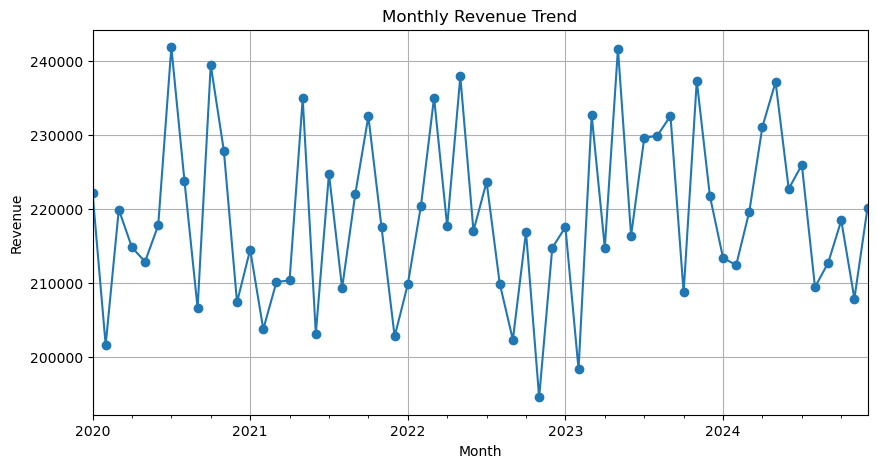

In [67]:
# Monthly Revenue Trend (Line Chart)
import matplotlib.pyplot as plt

monthly_rev = final_joined.groupby('month')['revenue'].sum()

plt.figure(figsize=(10,5))
monthly_rev.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [68]:
print("Total Revenue:", final_joined['revenue'].sum())


Total Revenue: 13131631.590000002


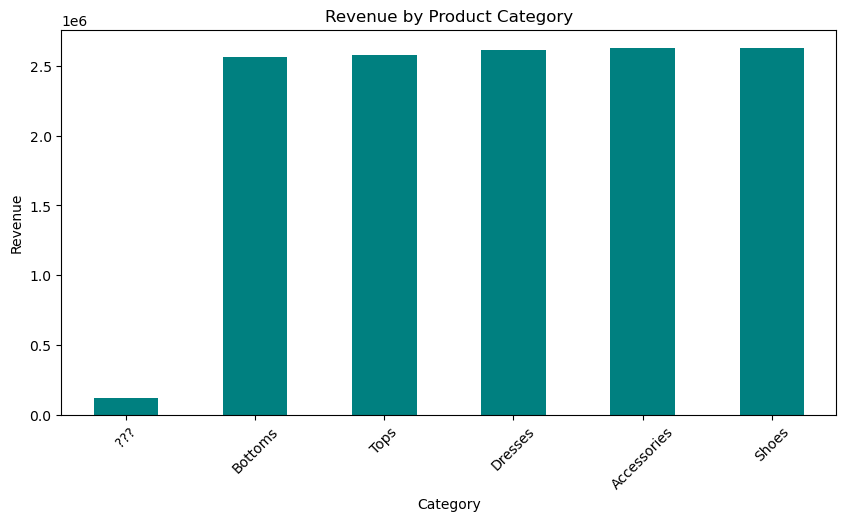

In [69]:
# . Revenue by Product Category (Bar Chart)
category_rev = final_joined.groupby('category')['revenue'].sum().sort_values()

plt.figure(figsize=(10,5))
category_rev.plot(kind='bar', color='teal')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


In [70]:
print("Top Category:", category_rev.idxmax())


Top Category: Shoes


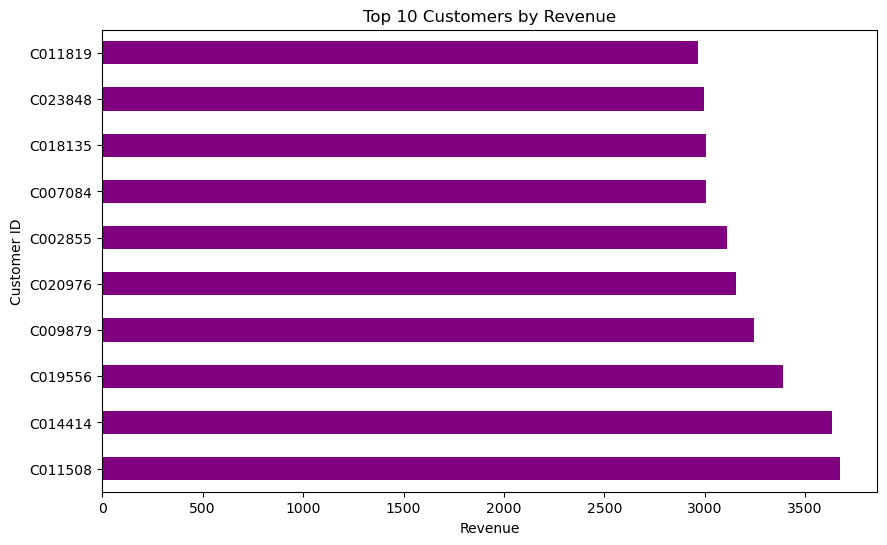

In [71]:
# Top 10 Customers by Revenue (Horizontal Bar Chart)
customer_rev = final_joined.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
customer_rev.plot(kind='barh', color='purple')
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()


In [72]:
print("Highest Paying Customer:", customer_rev.idxmax())


Highest Paying Customer: C011508


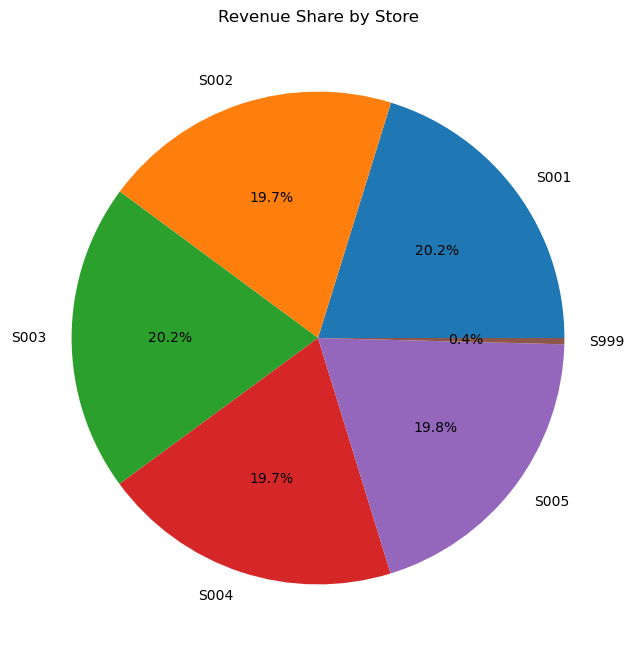

In [73]:
# Revenue by Store (Pie Chart)
store_rev = final_joined.groupby('store_id')['revenue'].sum()

plt.figure(figsize=(8,8))
store_rev.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue Share by Store")
plt.ylabel("")
plt.show()


In [74]:
print("Store with Highest Revenue:", store_rev.idxmax())


Store with Highest Revenue: S003


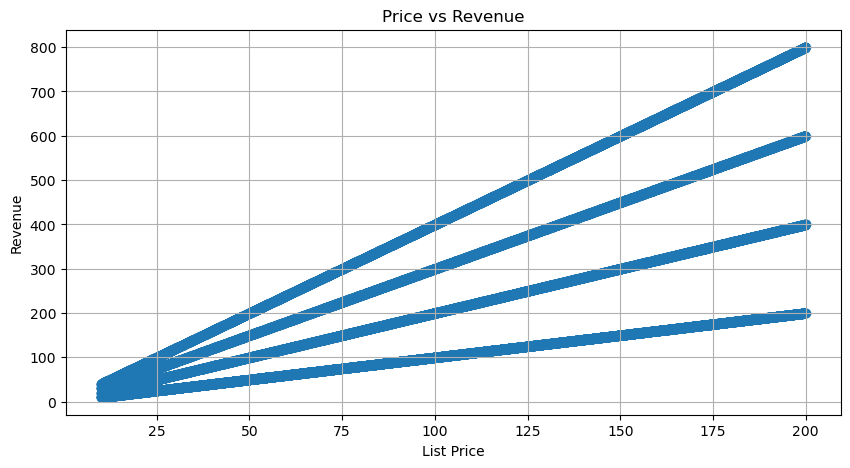

In [75]:
# Relationship Between Price and Revenue (Scatter Plot)
plt.figure(figsize=(10,5))
plt.scatter(final_joined['list_price'], final_joined['revenue'], alpha=0.5)
plt.title("Price vs Revenue")
plt.xlabel("List Price")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [76]:
print("Correlation Price–Revenue:", final_joined['list_price'].corr(final_joined['revenue']))


Correlation Price–Revenue: 0.7183675831025668
